In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("oilsands_master_full_with_dates.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1483 entries, 0 to 1482
Data columns (total 93 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   lake                                 1483 non-null   object 
 1   sampling_timestamp                   817 non-null    object 
 2   sample_timestamp                     817 non-null    object 
 3   site_name                            817 non-null    object 
 4   station_name                         817 non-null    object 
 5   depth                                64 non-null     float64
 6   value_sign                           817 non-null    object 
 7   unit_symbol                          817 non-null    object 
 8   method                               984 non-null    float64
 9   laboratory                           984 non-null    object 
 10  sampling_number                      817 non-null    object 
 11  sample_number                 

In [4]:
for col in df.columns:
    print(repr(col))

'lake'
'sampling_timestamp'
'sample_timestamp'
'site_name'
'station_name'
'depth'
'value_sign'
'unit_symbol'
'method'
'laboratory'
'sampling_number'
'sample_number'
'rdl'
'sample_location'
'sample_type'
'aluminum_dissolved'
'aluminum_total_recoverable'
'calcium_dissolved'
'calcium_total'
'copper_dissolved'
'copper_total_recoverable'
'lead_dissolved'
'lead_total_recoverable'
'nickel_dissolved'
'nickel_total_recoverable'
'nitrogen_kjeldahl_dissolved'
'oxygen_biochemical_demand'
'oxygen_dissolved_percent_saturation'
'ph'
'phosphorus_total'
'phosphorus_total_dissolved'
'turbidity'
'vanadium_dissolved'
'vanadium_total_recoverable'
'distance_group'
'project_number'
'station_number'
'station'
'latitude_decimal_degrees'
'longitude_decimal_degrees'
'sample_datetime'
'station_type_code'
'sample_matrix_code'
'sample_type_code'
'collection_code'
'qc_sample_flag'
'sample_comment'
'continental_river_basin_code'
'river_basin_code'
'river_sub_basin_code'
'aluminum_extractable'
'calcium_dissolved_filte

In [5]:
df['unit symbol'] = df['unit_symbol']

mask = df['unit_symbol'] == 'mg/l'

num_cols = df.select_dtypes(include=['number']).columns

exclude = ['latitude_decimal_degrees', 'longitude_decimal_degrees']
num_cols = [c for c in num_cols if c not in exclude]

df.loc[mask, num_cols] = df.loc[mask, num_cols] * 1000

df.loc[mask, 'unit_symbol'] = 'µg/l'

df[['unit_symbol','calcium_dissolved']].head(30)

,unit_symbol,calcium_dissolved
0,µg/l,NaN
1,µg/l,NaN
2,µg/l,NaN
3,µg/l,NaN
4,µg/l,NaN
5,µg/l,NaN
6,µg/l,NaN
7,µg/l,NaN
8,µg/l,NaN
9,µg/l,NaN


In [6]:
df_numeric = df.copy()
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce')

bad_cols = ['rdl','sampling_number','sample_number','method','laboratory',
            'latitude_decimal_degrees','longitude_decimal_degrees']
df_numeric = df_numeric.drop(columns=[c for c in bad_cols if c in df_numeric.columns], errors='ignore')

df_numeric = df_numeric.dropna(axis=1, how='all')
df_numeric = df_numeric.loc[:, df_numeric.nunique() > 1]

df_numeric['sample_timestamp'] = df['sample_timestamp']

df_numeric.columns
df_numeric.head()
for col in df_numeric.columns:
    print(repr(col))

'depth'
'aluminum_dissolved'
'aluminum_total_recoverable'
'calcium_dissolved'
'calcium_total'
'copper_dissolved'
'copper_total_recoverable'
'lead_dissolved'
'lead_total_recoverable'
'nickel_dissolved'
'nickel_total_recoverable'
'oxygen_biochemical_demand'
'oxygen_dissolved_percent_saturation'
'ph'
'phosphorus_total'
'phosphorus_total_dissolved'
'turbidity'
'vanadium_dissolved'
'vanadium_total_recoverable'
'collection_code'
'calcium_dissolved_filtered'
'copper_total'
'lead_extractable'
'lead_total'
'nickel_total'
'nitrogen_dissolved_nitrate'
'nitrogen_dissolved_nitrite'
'oxygen_dissolved_field_meter'
'oxygen_total_cod'
'ph_lab'
'turbidity_jtu'
'turbidity_ntu'
'nitrogen_dissolved'
'value'
'aluminum dissolved'
'aluminum total recoverable'
'calcium dissolved'
'calcium total'
'copper dissolved'
'copper total recoverable'
'lead dissolved'
'lead total recoverable'
'nickel dissolved'
'nickel total recoverable'
'nitrogen dissolved'
'phosphorus total dissolved'
'phosphorus total'
'vanadium disso

In [7]:
import pandas as pd
import re

def clean_column(col):
    col = str(col).strip().lower()
    col = col.replace('%', 'percent')
    col = re.sub(r'[^\w]+', '_', col)
    col = re.sub(r'_+', '_', col)
    return col.strip('_')

df.columns = [clean_column(c) for c in df.columns]


rename_map = {
    'ph_lab': 'ph',
    'ph_units': 'ph',

    'turbidity_jtu': 'turbidity',
    'turbidity_ntu': 'turbidity',

    'nitrogen_dissolved_no3_no2': 'nitrogen_dissolved',
    'nitrogen_dissolved_nitrate': 'nitrogen_dissolved',
    'nitrogen_dissolved_nitrite': 'nitrogen_dissolved',
}

df = df.rename(columns=lambda c: rename_map.get(c, c))


def merge_duplicates(df):
    merged = pd.DataFrame(index=df.index)

    for col in pd.unique(df.columns):
        same_cols = df.loc[:, df.columns == col]

        if same_cols.shape[1] == 1:
            merged[col] = same_cols.iloc[:, 0]
        else:
            merged[col] = same_cols.bfill(axis=1).iloc[:, 0]

    return merged

df = merge_duplicates(df)


drop_cols = ['collection_code', 'value', 'rdl', 'method']
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')


y = df['distance_group'].copy() if 'distance_group' in df.columns else None


analysis_vars = [
    'depth',
    'aluminum_dissolved',
    'aluminum_total_recoverable',
    'calcium_dissolved',
    'calcium_total',
    'copper_dissolved',
    'copper_total_recoverable',
    'lead_dissolved',
    'lead_total_recoverable',
    'nickel_dissolved',
    'nickel_total_recoverable',
    'oxygen_biochemical_demand',
    'oxygen_dissolved_percent_saturation',
    'ph',
    'phosphorus_total',
    'phosphorus_total_dissolved',
    'turbidity',
    'vanadium_dissolved',
    'vanadium_total_recoverable',
    'calcium_dissolved_filtered',
    'copper_total',
    'lead_extractable',
    'lead_total',
    'nickel_total',
    'nitrogen_dissolved',
    'oxygen_dissolved_field_meter',
    'oxygen_total_cod',
    'oxygen_dissolved_winkler'
]

available_vars = [c for c in analysis_vars if c in df.columns]

df_numeric = df[available_vars].copy()
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce')


df_numeric = df_numeric.dropna(axis=1, how='all')
df_numeric = df_numeric.loc[:, df_numeric.nunique() > 1]


df_numeric['sample_date'] = pd.to_datetime(
    df['sample_timestamp']
    .fillna(df['sample_datetime'])
    .fillna(df['sampling_timestamp'])
)
df_numeric['lake'] = df['lake']
df_numeric['distance_group'] = df['distance_group']

print("Final columns used:")
print(df_numeric.columns.tolist())

print("Shape:", df_numeric.shape)

df_numeric.head()

Final columns used:
['depth', 'aluminum_dissolved', 'aluminum_total_recoverable', 'calcium_dissolved', 'calcium_total', 'copper_dissolved', 'copper_total_recoverable', 'lead_dissolved', 'lead_total_recoverable', 'nickel_dissolved', 'nickel_total_recoverable', 'oxygen_biochemical_demand', 'oxygen_dissolved_percent_saturation', 'ph', 'phosphorus_total', 'phosphorus_total_dissolved', 'turbidity', 'vanadium_dissolved', 'vanadium_total_recoverable', 'calcium_dissolved_filtered', 'copper_total', 'lead_extractable', 'lead_total', 'nickel_total', 'nitrogen_dissolved', 'oxygen_dissolved_field_meter', 'oxygen_total_cod', 'oxygen_dissolved_winkler', 'sample_date', 'lake', 'distance_group']
Shape: (1483, 31)


,depth,aluminum_dissolved,aluminum_total_recoverable,calcium_dissolved,calcium_total,copper_dissolved,copper_total_recoverable,lead_dissolved,lead_total_recoverable,nickel_dissolved,...,lead_extractable,lead_total,nickel_total,nitrogen_dissolved,oxygen_dissolved_field_meter,oxygen_total_cod,oxygen_dissolved_winkler,sample_date,lake,distance_group
0,NaN,1.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-07-30 11:00:00,Isadore,Near
1,NaN,1.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005-08-01 11:00:00,Isadore,Near
2,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-07-24 11:00:00,Isadore,Near
3,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007-07-20 11:00:00,Isadore,Near
4,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-07-14 11:00:00,Isadore,Near


In [8]:
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1483 entries, 0 to 1482
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   depth                                64 non-null     float64       
 1   aluminum_dissolved                   65 non-null     float64       
 2   aluminum_total_recoverable           72 non-null     float64       
 3   calcium_dissolved                    124 non-null    float64       
 4   calcium_total                        71 non-null     float64       
 5   copper_dissolved                     65 non-null     float64       
 6   copper_total_recoverable             72 non-null     float64       
 7   lead_dissolved                       65 non-null     float64       
 8   lead_total_recoverable               72 non-null     float64       
 9   nickel_dissolved                     65 non-null     float64       
 10  nickel_total

In [9]:
df_numeric.head(10)

,depth,aluminum_dissolved,aluminum_total_recoverable,calcium_dissolved,calcium_total,copper_dissolved,copper_total_recoverable,lead_dissolved,lead_total_recoverable,nickel_dissolved,...,lead_extractable,lead_total,nickel_total,nitrogen_dissolved,oxygen_dissolved_field_meter,oxygen_total_cod,oxygen_dissolved_winkler,sample_date,lake,distance_group
0,NaN,1.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-07-30 11:00:00,Isadore,Near
1,NaN,1.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005-08-01 11:00:00,Isadore,Near
2,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-07-24 11:00:00,Isadore,Near
3,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007-07-20 11:00:00,Isadore,Near
4,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-07-14 11:00:00,Isadore,Near
5,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-09-13 11:00:00,Isadore,Near
6,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-09-11 11:00:00,Isadore,Near
7,NaN,2.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-09-12 11:00:00,Isadore,Near
8,NaN,3.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-09-06 11:00:00,Isadore,Near
9,NaN,0.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-09-03 11:00:00,Isadore,Near


In [10]:
df_numeric['sample_date'] = pd.to_datetime(df_numeric['sample_date'])
df_numeric['sample_date'] = df_numeric['sample_date'].dt.floor('D')



In [11]:
df_merged = df_numeric.groupby(['lake', 'sample_date']).agg(
    lambda col: col.median() if col.dtype != 'object' else col.dropna().iloc[0] if col.notna().any() else None
).reset_index()

C:\Users\morsal.n\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\morsal.n\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\morsal.n\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\morsal.n\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\morsal.n\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

In [12]:
df_merged.head(10)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   lake                                 146 non-null    object        
 1   sample_date                          146 non-null    datetime64[ns]
 2   depth                                4 non-null      float64       
 3   aluminum_dissolved                   65 non-null     float64       
 4   aluminum_total_recoverable           71 non-null     float64       
 5   calcium_dissolved                    84 non-null     float64       
 6   calcium_total                        65 non-null     float64       
 7   copper_dissolved                     65 non-null     float64       
 8   copper_total_recoverable             71 non-null     float64       
 9   lead_dissolved                       65 non-null     float64       
 10  lead_total_rec

In [13]:
df_merged['calcium_dissolved'] = (
    df_merged['calcium_dissolved']
    .combine_first(df_merged['calcium_dissolved_filtered'])
)

df_merged['copper_total_recoverable'] = (
    df_merged['copper_total_recoverable']
    .combine_first(df_merged['copper_total'])
)

df_merged['lead_total_recoverable'] = (
    df_merged['lead_total_recoverable']
    .combine_first(df_merged['lead_total'])
)

df_merged['nickel_total_recoverable'] = (
    df_merged['nickel_total_recoverable']
    .combine_first(df_merged['nickel_total'])
)


In [14]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   lake                                 146 non-null    object        
 1   sample_date                          146 non-null    datetime64[ns]
 2   depth                                4 non-null      float64       
 3   aluminum_dissolved                   65 non-null     float64       
 4   aluminum_total_recoverable           71 non-null     float64       
 5   calcium_dissolved                    95 non-null     float64       
 6   calcium_total                        65 non-null     float64       
 7   copper_dissolved                     65 non-null     float64       
 8   copper_total_recoverable             77 non-null     float64       
 9   lead_dissolved                       65 non-null     float64       
 10  lead_total_rec

In [15]:
df_clean = df_merged.drop(columns=['depth'])

df_clean = df_clean.loc[:, df_clean.isnull().mean() < 0.9]

In [16]:
df_clean['lake'].value_counts()

lake
Kearl         43
Gregoire      41
Namur         30
McClelland    13
Isadore       12
Mildred        7
Name: count, dtype: int64

In [17]:
df_merged['lake'].value_counts()

lake
Kearl         43
Gregoire      41
Namur         30
McClelland    13
Isadore       12
Mildred        7
Name: count, dtype: int64

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   lake                          146 non-null    object        
 1   sample_date                   146 non-null    datetime64[ns]
 2   aluminum_dissolved            65 non-null     float64       
 3   aluminum_total_recoverable    71 non-null     float64       
 4   calcium_dissolved             95 non-null     float64       
 5   calcium_total                 65 non-null     float64       
 6   copper_dissolved              65 non-null     float64       
 7   copper_total_recoverable      77 non-null     float64       
 8   lead_dissolved                65 non-null     float64       
 9   lead_total_recoverable        75 non-null     float64       
 10  nickel_dissolved              65 non-null     float64       
 11  nickel_total_recoverable      77

In [19]:
numeric_cols = df_clean.select_dtypes(include='float64').columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   lake                          146 non-null    object        
 1   sample_date                   146 non-null    datetime64[ns]
 2   aluminum_dissolved            146 non-null    float64       
 3   aluminum_total_recoverable    146 non-null    float64       
 4   calcium_dissolved             146 non-null    float64       
 5   calcium_total                 146 non-null    float64       
 6   copper_dissolved              146 non-null    float64       
 7   copper_total_recoverable      146 non-null    float64       
 8   lead_dissolved                146 non-null    float64       
 9   lead_total_recoverable        146 non-null    float64       
 10  nickel_dissolved              146 non-null    float64       
 11  nickel_total_recoverable      14

In [20]:
df_clean['distance_group'].value_counts()

distance_group
Far     71
Mid     56
Near    19
Name: count, dtype: int64

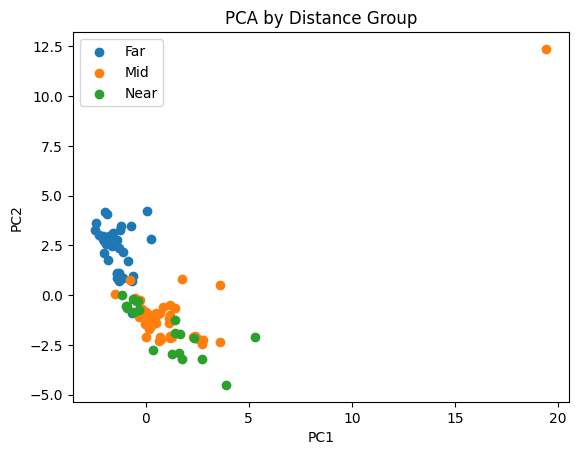

[0.22673115 0.20841928]


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Keep ONLY rows that have distance_group
df_pca_input = df_clean.dropna(subset=['distance_group'])

# Separate features + labels
X = df_pca_input.drop(columns=['lake', 'sample_date', 'distance_group'])
labels = df_pca_input['distance_group']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create dataframe
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['distance_group'] = labels.values

unique_groups = sorted(df_pca['distance_group'].unique())

for group in unique_groups:
    subset = df_pca[df_pca['distance_group'] == group]
    plt.scatter(subset['PC1'], subset['PC2'], label=group)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA by Distance Group')
plt.legend()
plt.show()
print(pca.explained_variance_ratio_)

<Axes: xlabel='PC1', ylabel='PC2'>

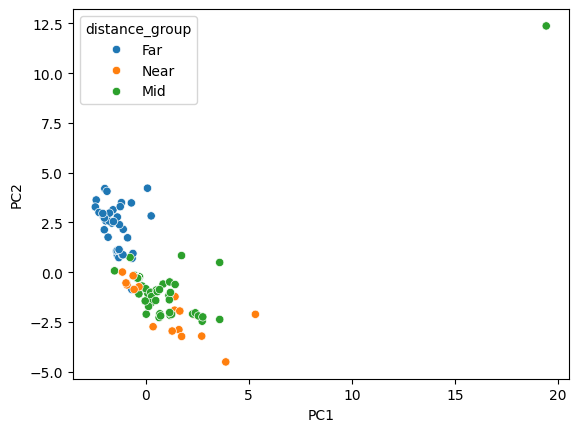

In [22]:
import seaborn as sns
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='distance_group')

In [23]:
df_clean.to_csv('PCAplotdata.csv')